# Подготовка данных

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from db.core import db_to_csv
db_to_csv()

2026-04-06 17:45:51.134 | INFO     | db.core:db_to_csv:72 - Таблица sliver_predict_cost экспортирована в CSV.
2026-04-06 17:45:51.231 | INFO     | db.core:db_to_csv:72 - Таблица copper_predict_cost экспортирована в CSV.
2026-04-06 17:45:51.357 | INFO     | db.core:db_to_csv:72 - Таблица gold_cost экспортирована в CSV.
2026-04-06 17:45:51.494 | INFO     | db.core:db_to_csv:72 - Таблица sliver_cost экспортирована в CSV.
2026-04-06 17:45:51.609 | INFO     | db.core:db_to_csv:72 - Таблица copper_cost экспортирована в CSV.
2026-04-06 17:45:51.676 | INFO     | db.core:db_to_csv:72 - Таблица gold_predict_cost экспортирована в CSV.
2026-04-06 17:45:52.012 | INFO     | db.core:db_to_csv:72 - Таблица gold_news экспортирована в CSV.
2026-04-06 17:45:52.097 | INFO     | db.core:db_to_csv:72 - Таблица sliver_news экспортирована в CSV.
2026-04-06 17:45:52.186 | INFO     | db.core:db_to_csv:72 - Таблица copper_news экспортирована в CSV.


In [3]:
df_gold_cost = pd.read_csv('data/gold_cost.csv', index_col='date')

In [4]:
df_gold_cost.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1750 entries, 2019-04-08 to 2026-04-03
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   open    1750 non-null   float64
 1   high    1750 non-null   float64
 2   low     1750 non-null   float64
 3   close   1750 non-null   float64
dtypes: float64(4)
memory usage: 68.4+ KB


In [5]:
# def tonality(df_news, df_cost) -> pd.DataFrame:
#     tonality_dict = {}
#     for idx, row in df_cost.iterrows():
#         tonality_dict[row['date']] = 1 if row['open'] < row['close'] else -1
#     df_news['tonality'] = df_news['date'].map(tonality_dict)
#
#     return df_news
#
# tonality(df_gold_news,df_gold_cost)

# Работа с временными рядами

In [6]:
df_gold_cost_close = df_gold_cost[['close']]

In [7]:
df_gold_cost_close.head()

,close
date,
2019-04-08,2718.5
2019-04-09,2710.0
2019-04-10,2707.5
2019-04-11,2689.0
2019-04-12,2677.5


<Axes: xlabel='date'>

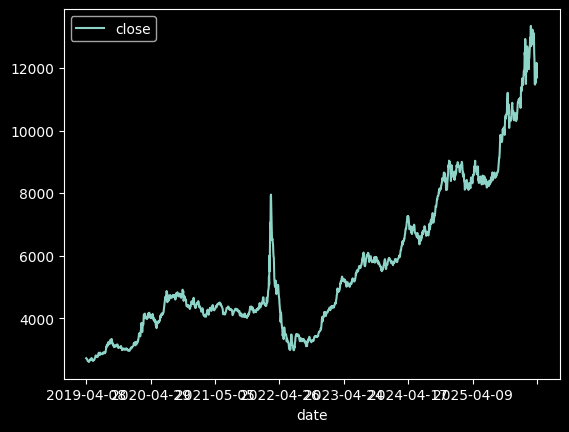

In [8]:
df_gold_cost_close.plot()

## Moving Average

In [9]:
def moving_average(df, window_size):
    return df.rolling(window=window_size, min_periods=1).mean()

In [10]:
df_gcc_ma = moving_average(df_gold_cost_close, window_size=30)
df_gcc_ma.head()

,close
date,
2019-04-08,2718.50
2019-04-09,2714.25
2019-04-10,2712.00
2019-04-11,2706.25
2019-04-12,2700.50


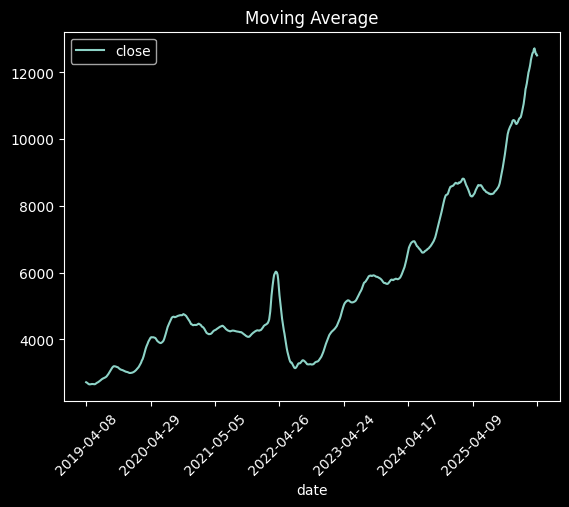

In [11]:
df_gcc_ma.plot()
plt.xticks(rotation=45)
plt.title('Moving Average')
plt.show()

In [12]:
# Рассчет среднеквадратичного отклонения
simg = np.sqrt(np.mean((df_gold_cost_close['close'] - df_gcc_ma['close']) ** 2))
print(f"Среднеквадратичное отклонение: {simg}")

Среднеквадратичное отклонение: 334.0779068060711


In [13]:
df_gcc_ma['close_plus_1.5_sigm'] = df_gcc_ma['close'] + 1.5 * simg
df_gcc_ma['close_minus_1.5_sigm'] = df_gcc_ma['close'] - 1.5 * simg
df_gcc_ma['real_close'] = df_gold_cost_close['close']
df_gcc_ma.rename({'close': 'moving_average'}, axis=1, inplace=True)

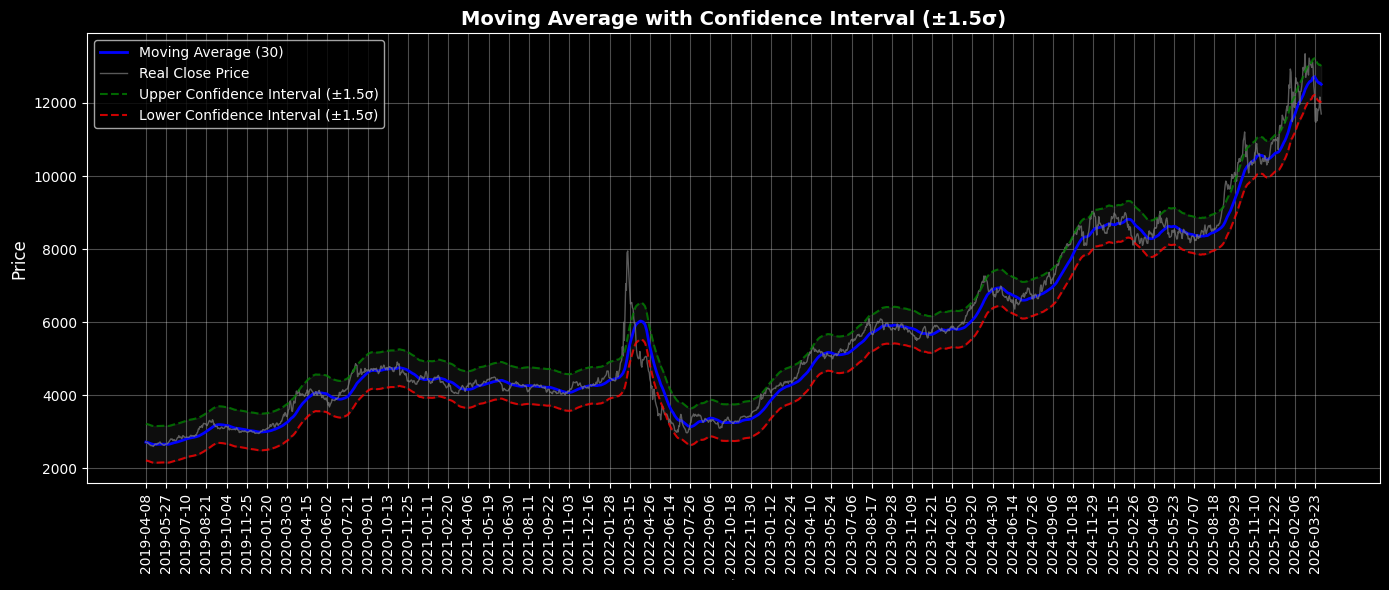

In [14]:
# Построение графика с доверительным интервалом
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(df_gcc_ma.index, df_gcc_ma['moving_average'], label='Moving Average (30)', linewidth=2, color='blue')
ax.plot(df_gcc_ma.index, df_gcc_ma['real_close'], label='Real Close Price', linewidth=1, alpha=0.7, color='gray')

ax.plot(df_gcc_ma.index, df_gcc_ma['close_plus_1.5_sigm'], linestyle='--', linewidth=1.5, color='green', label='Upper Confidence Interval (±1.5σ)', alpha=0.8)
ax.plot(df_gcc_ma.index, df_gcc_ma['close_minus_1.5_sigm'], linestyle='--', linewidth=1.5, color='red', label='Lower Confidence Interval (±1.5σ)', alpha=0.8)

ax.fill_between(df_gcc_ma.index, df_gcc_ma['close_minus_1.5_sigm'], df_gcc_ma['close_plus_1.5_sigm'], alpha=0.1, color='gray')

ax.set_xlabel('Date', fontsize=1)
ax.set_ylabel('Price', fontsize=12)
ax.set_title('Moving Average with Confidence Interval (±1.5σ)', fontsize=14, fontweight='bold')
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3)
plt.xticks(df_gcc_ma.index[::30],rotation=90)
plt.tight_layout()
plt.show()

# LSTM

In [26]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.preprocessing import MinMaxScaler

In [61]:
df_gold_cost.head()

,open,high,low,close
date,,,,
2019-04-08,2718.5,2727.5,2718.5,2718.5
2019-04-09,2705.0,2710.0,2705.0,2710.0
2019-04-10,2716.0,2716.0,2704.5,2707.5
2019-04-11,2702.0,2702.0,2685.0,2689.0
2019-04-12,2683.5,2683.5,2670.0,2677.5


In [62]:
df_gold_cost_lstm = df_gold_cost.copy()
scaler = MinMaxScaler()
scaler.fit(df_gold_cost_lstm)
df_gold_cost_lstm = pd.DataFrame(scaler.transform(df_gold_cost_lstm), columns=df_gold_cost_lstm.columns, index=df_gold_cost_lstm.index)

In [81]:
df_gold_cost_train = df_gold_cost_lstm[:-60].copy()
df_gold_cost_test = df_gold_cost_lstm[-60:].copy()

In [82]:
timesteps = 30

In [83]:
def make_sequences(data, timesteps=60):
    X, y = [], []
    values = data.values
    for i in range(len(values) - timesteps):
        X.append(values[i:i+timesteps])
        y.append(values[i+timesteps])
    return np.array(X), np.array(y)

In [84]:
X_train, y_train = make_sequences(df_gold_cost_train, timesteps)
X_test, y_test = make_sequences(df_gold_cost_test, timesteps)

In [85]:
model = Sequential([
    LSTM(64, input_shape=(timesteps, 4), return_sequences=True),
    Dropout(0.2),
    LSTM(32),
    Dense(4)
])
model.compile(optimizer='adam', loss='mse', metrics=['mae'])
history = model.fit(X_train, y_train, epochs=30, batch_size=32, validation_split=0.2)

Epoch 1/30


D:\SUAI\Diplom\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


42/42 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - loss: 0.0059 - mae: 0.0490 - val_loss: 0.0079 - val_mae: 0.0693
Epoch 2/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 5.9319e-04 - mae: 0.0155 - val_loss: 0.0027 - val_mae: 0.0404
Epoch 3/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 5.4961e-04 - mae: 0.0144 - val_loss: 0.0027 - val_mae: 0.0382
Epoch 4/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 5.1419e-04 - mae: 0.0140 - val_loss: 0.0024 - val_mae: 0.0384
Epoch 5/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 4.8453e-04 - mae: 0.0133 - val_loss: 0.0018 - val_mae: 0.0310
Epoch 6/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 4.4017e-04 - mae: 0.0129 - val_loss: 0.0012 - val_mae: 0.0267
Epoch 7/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 4.3649e-04 - mae: 0.0130 - val_loss: 0.0016 - val_mae: 0.0313
Epoch 8/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 3.7560e-04 - mae: 0.0122 - val_loss: 0.0015 - val_mae: 0.0301
Epoch 9/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/s

In [86]:
pred = model.predict(X_test[:60])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 433ms/step


In [87]:
pred

array([[0.81321615, 0.78304964, 0.81069267, 0.7757384 ],
       [0.8241159 , 0.795422  , 0.81868565, 0.785681  ],
       [0.84244984, 0.8151075 , 0.8324357 , 0.8031436 ],
       [0.8623455 , 0.83556485, 0.84772193, 0.8229772 ],
       [0.8750369 , 0.84754175, 0.85769904, 0.8365073 ],
       [0.8806214 , 0.85147923, 0.8621135 , 0.8428363 ],
       [0.89335924, 0.86320716, 0.87147087, 0.85450494],
       [0.886029  , 0.8536522 , 0.86510724, 0.8478444 ],
       [0.8727531 , 0.8381753 , 0.85425663, 0.8344082 ],
       [0.8646236 , 0.82911175, 0.8472295 , 0.82478887],
       [0.8622262 , 0.8267637 , 0.84463334, 0.8206815 ],
       [0.8568979 , 0.82142293, 0.8401588 , 0.81474525],
       [0.86644775, 0.8320104 , 0.8469318 , 0.8223871 ],
       [0.87713045, 0.8435386 , 0.85500455, 0.8324143 ],
       [0.88284326, 0.84917265, 0.8595239 , 0.83852905],
       [0.88304454, 0.8486497 , 0.8598604 , 0.8394502 ],
       [0.8776087 , 0.84222823, 0.8558565 , 0.83477044],
       [0.87609696, 0.8403112 ,

In [90]:
pred_real = scaler.inverse_transform(pred)


In [91]:
y_test_real = scaler.inverse_transform(y_test)

In [92]:
from sklearn.metrics import mean_absolute_error

columns = df_gold_cost.columns
mae_dict = {}

for i, col in enumerate(columns):
    mae = mean_absolute_error(y_test_real[:, i], pred_real[:, i])
    mae_dict[col] = mae
    print(f"MAE для {col}: {mae:.4f}")

MAE для open: 682.6939
MAE для high: 1129.7198
MAE для low: 1337.1886
MAE для close: 1285.4182
